In [ ]:
from pathlib import Path
resultsdir = Path("/data4/Henri/j3/framewiseSpeakerCounting/results/J1_BXLS_seglen_OracleSAD_STC500ms")

In [6]:
# The first step is to load all csv files in resultsdir and concatenate them into a single dataframe
# important: every method has its own csv file and the method name is part of the filename but not the content
# I provide a list of the method names to load
method_names_long = [
  # "C",
  # "CSn",
  # "CWn",
  "RTF_Estimator_CSv",
  "RTF_Estimator_CWv",
  "RTF_Estimator_BOP", 
  "RTF_Estimator_BOP_S", 
  "RTF_Estimator_BOP_W", 
  "RTF_Estimator_BOPO", 
  "RTF_Estimator_BOPO_S", 
  "RTF_Estimator_BOPO_W",
  # "CB",
  # "CB-S",
  # "CB-W",
  # "CBW",
  # "online-cgmm-mvdr",
  "BlockOnlineGSS",
  "RTF_Estimator_Oracle", 
]
method_names_short = [
  # "C",
  # "CSn",
  # "CWn",
  "CSv",
  "CWv",
  "BOP", 
  "BOP-S", 
  "BOP-W", 
  "BOPO", 
  "BOPO-S", 
  "BOPO-W",
  # "CB",
  # "CB-S",
  # "CB-W",
  # "CBW",
  # "online-cgmm-mvdr",
  "GSS",
  "Oracle", 
]


In [7]:
# Now load the csv files and concatenate them into a single dataframe
import pandas as pd
df_list = []
for method_short, method_long in zip(method_names_short, method_names_long):
    csv_file = resultsdir / f"{method_long}_results.csv"
    if csv_file.exists():
        # note that the first colum is the scenario_id which should be the index of the df
        df = pd.read_csv(csv_file, index_col=0)
        df["method"] = method_short  # add a column for the method name
        # Append method name to index to ensure uniqueness across the combined dataframe
        df.index = df.index.astype(str) + "_" + method_short
        df_list.append(df)
    else:
        print(f"Warning: {csv_file} does not exist and will be skipped.")

In [8]:
# Concatenate all dataframes
df_all = pd.concat(df_list)
print("Combined dataframe shape:", df_all.shape)
# print an overview of all columns
print("Columns in the combined dataframe:", df_all.columns)

Combined dataframe shape: (26400, 105)
Columns in the combined dataframe: Index(['MHA', 'WMHA', 'MHA_A1', 'WMHA_A1', 'MHA_A2', 'WMHA_A2', 'MHA_A3',
       'WMHA_A3', 'MHA_D1', 'WMHA_D1',
       ...
       'DSTOI_A3', 'STOIi_D1', 'STOIo_D1', 'DSTOI_D1', 'STOIi_D2', 'STOIo_D2',
       'DSTOI_D2', 'input_snr', 'fixed_seg_length', 'method'],
      dtype='object', length=105)


In [9]:
# For all columns with MHA in their name, they are Hermitian Angle metrics up to now in radians,
# convert them to degrees for better interpretability
mha_columns = [col for col in df_all.columns if "MHA" in col]
for col in mha_columns:
    df_all[col] = df_all[col] * (180.0 / 3.141592653589793)  # radians to degrees

In [10]:
df_all

,MHA,WMHA,MHA_A1,WMHA_A1,MHA_A2,WMHA_A2,MHA_A3,WMHA_A3,MHA_D1,WMHA_D1,...,DSTOI_A3,STOIi_D1,STOIo_D1,DSTOI_D1,STOIi_D2,STOIo_D2,DSTOI_D2,input_snr,fixed_seg_length,method
scenario_id,,,,,,,,,,,,,,,,,,,,,
J1_BXLS_seglen_test_generator_0_CSv,29.492736,17.416328,18.482166,16.562533,55.624118,32.634569,44.325483,20.740339,NaN,NaN,...,0.099482,NaN,NaN,NaN,NaN,NaN,NaN,10,1.024,CSv
J1_BXLS_seglen_test_generator_1_CSv,22.792773,18.096354,31.478802,21.118293,26.610494,28.061224,56.586854,41.867762,NaN,NaN,...,0.031208,NaN,NaN,NaN,NaN,NaN,NaN,10,0.512,CSv
J1_BXLS_seglen_test_generator_10_CSv,25.245187,21.309155,12.243906,8.569451,41.887337,32.133458,34.424140,34.045618,NaN,NaN,...,0.024477,NaN,NaN,NaN,NaN,NaN,NaN,10,2.048,CSv
J1_BXLS_seglen_test_generator_100_CSv,26.293816,14.657045,25.613185,8.146016,26.514238,20.004497,40.106352,23.263655,NaN,NaN,...,0.015617,NaN,NaN,NaN,NaN,NaN,NaN,10,2.048,CSv
J1_BXLS_seglen_test_generator_1000_CSv,22.357489,18.159839,12.291383,6.290705,17.585005,23.513261,42.872783,29.286444,NaN,NaN,...,0.085468,NaN,NaN,NaN,NaN,NaN,NaN,15,4.096,CSv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
J1_BXLS_seglen_test_generator_995_Oracle,0.000338,0.000509,0.002273,0.002378,0.002096,0.001231,0.002141,0.006195,NaN,NaN,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,5,0.064,Oracle
J1_BXLS_seglen_test_generator_996_Oracle,0.002179,0.002338,0.002315,0.003128,0.002652,0.002620,0.002123,0.001861,NaN,NaN,...,0.325265,NaN,NaN,NaN,NaN,NaN,NaN,0,4.096,Oracle
J1_BXLS_seglen_test_generator_997_Oracle,0.000509,0.000215,0.001971,0.000946,0.001967,0.000687,0.001727,0.000760,NaN,NaN,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0,0.128,Oracle


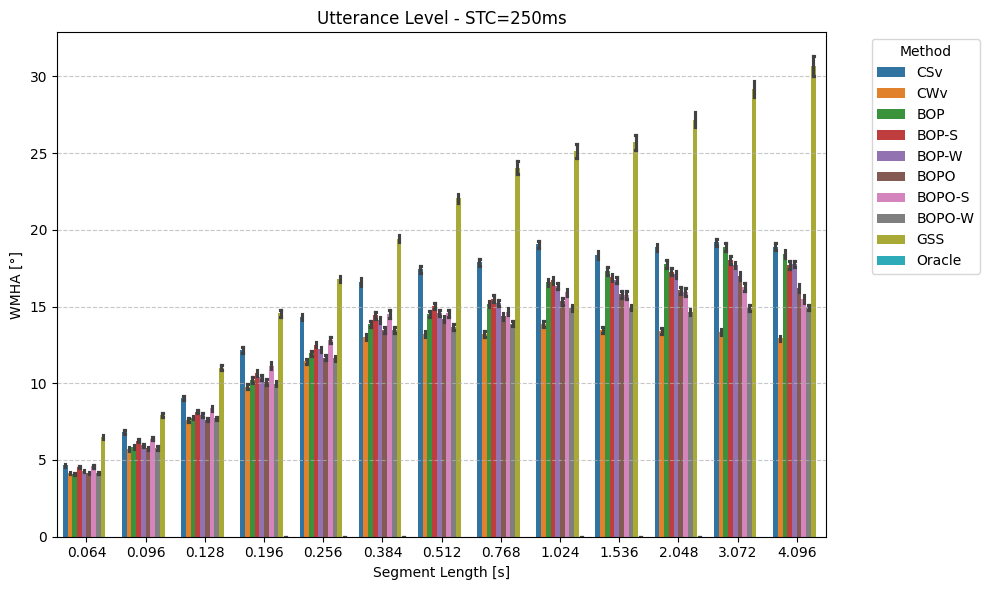

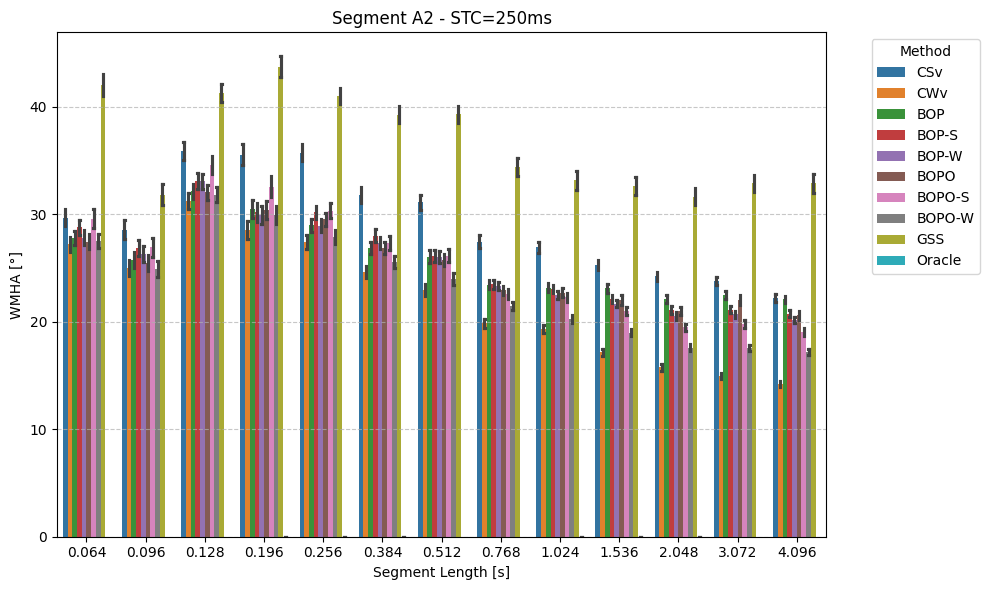

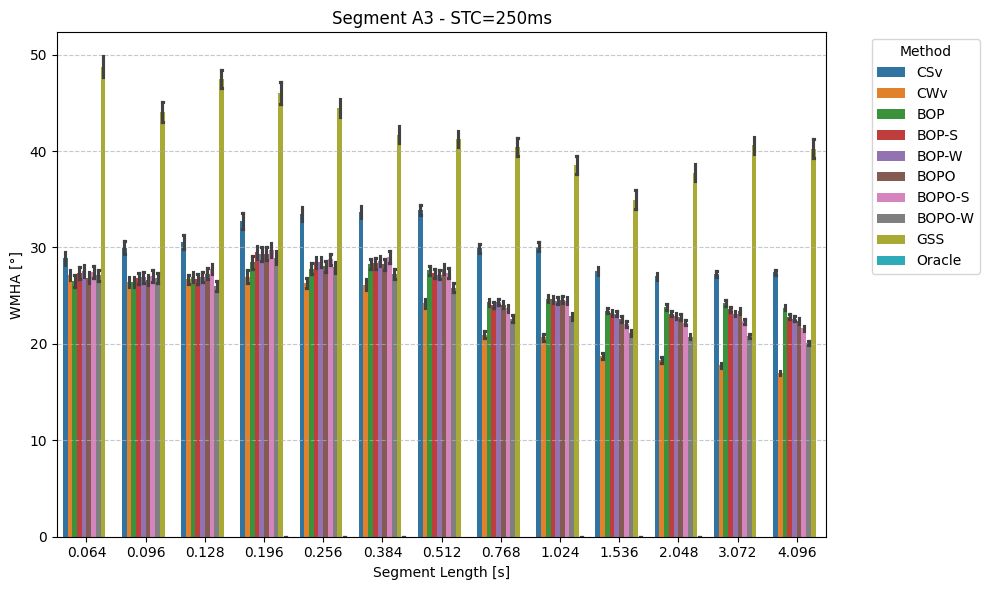

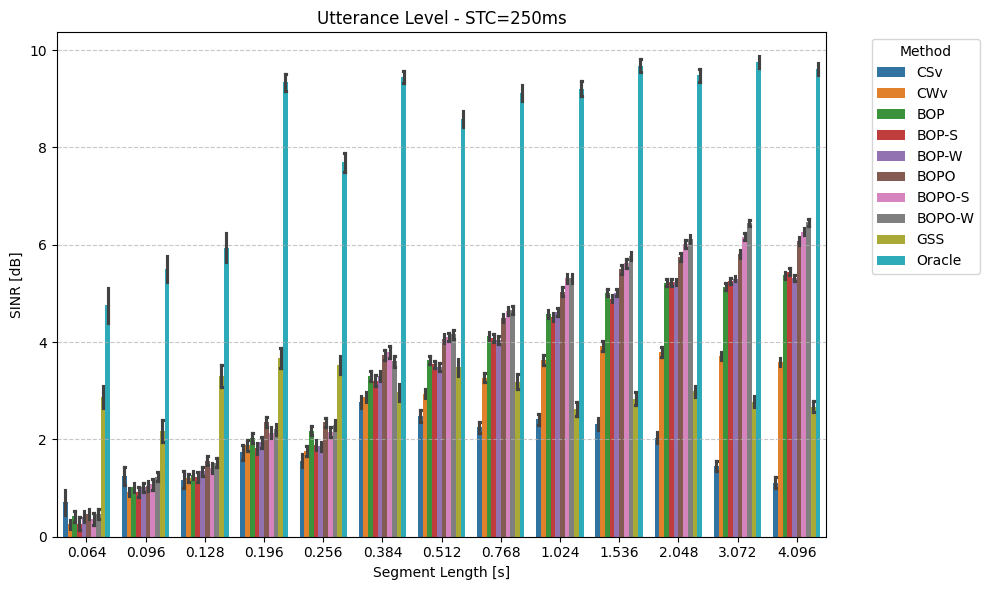

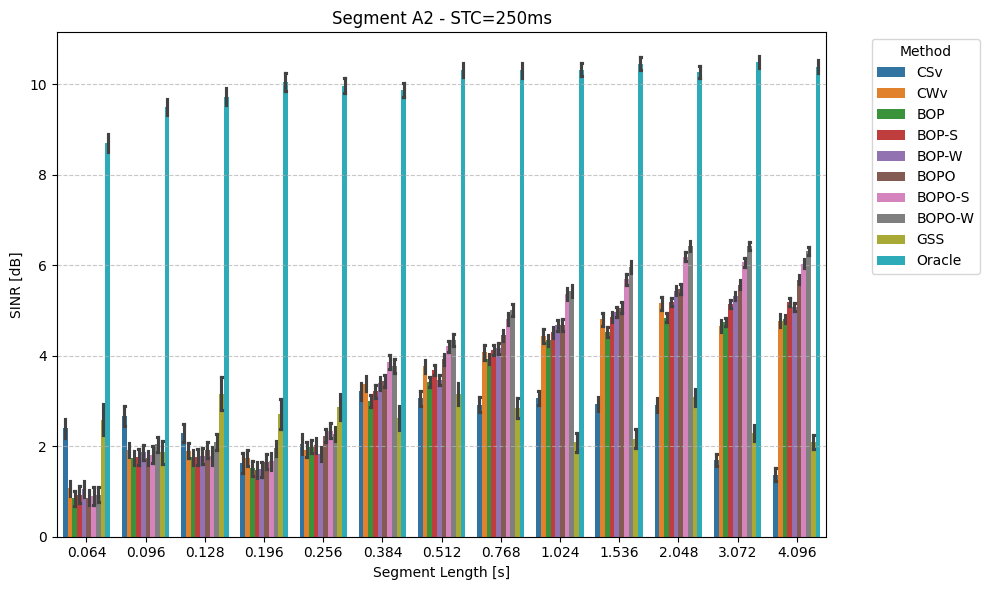

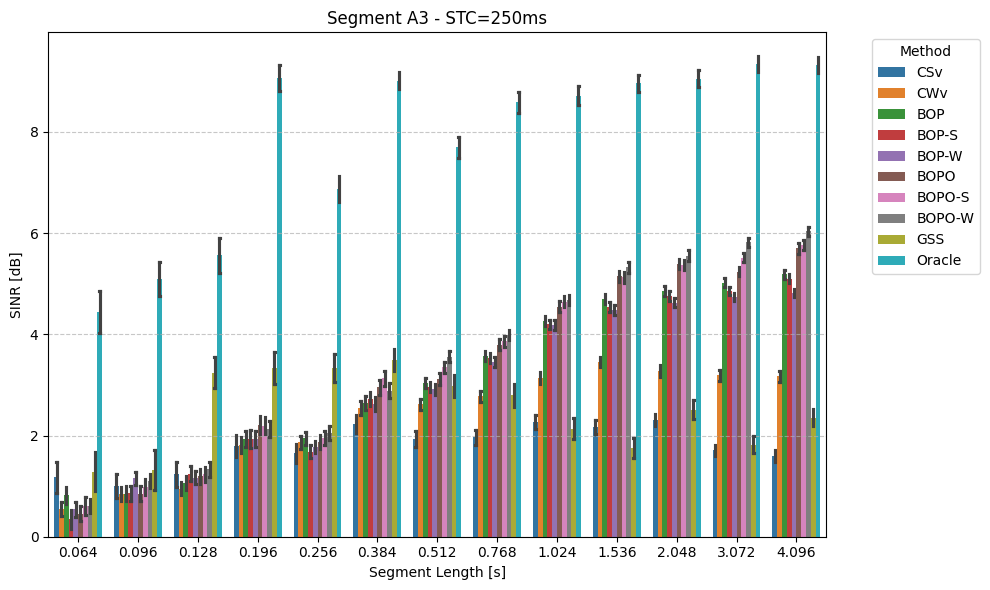

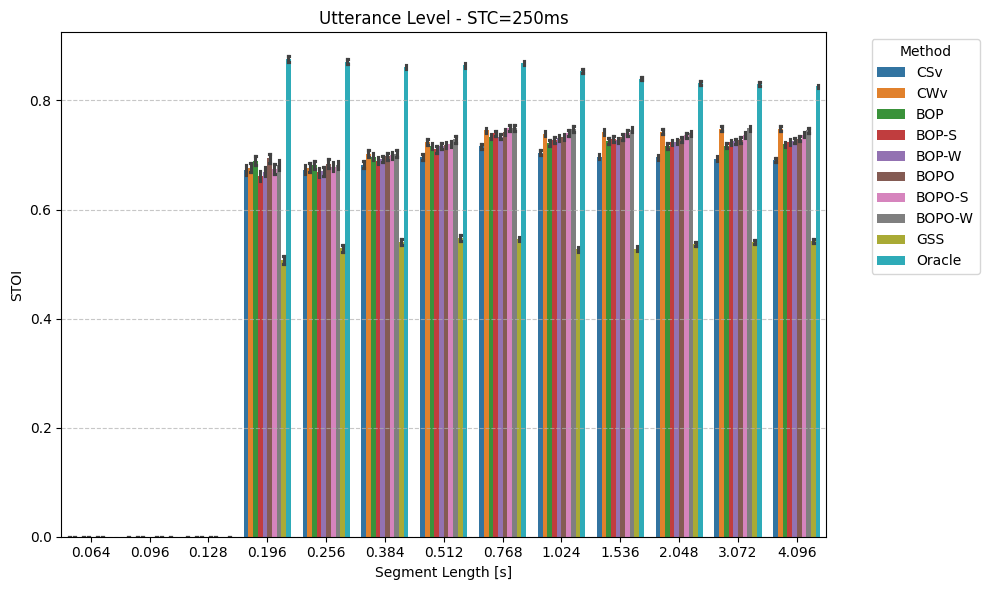

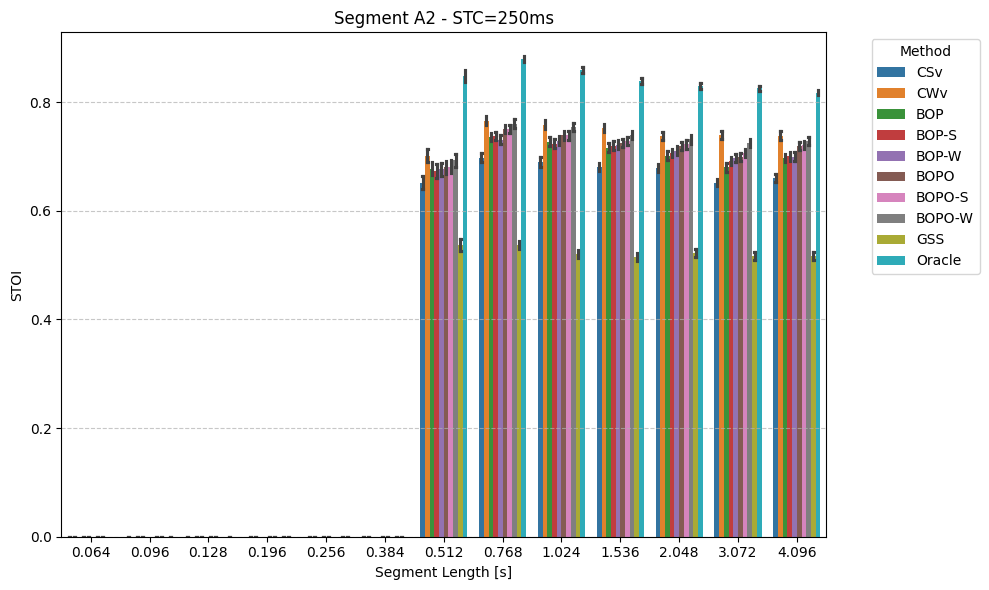

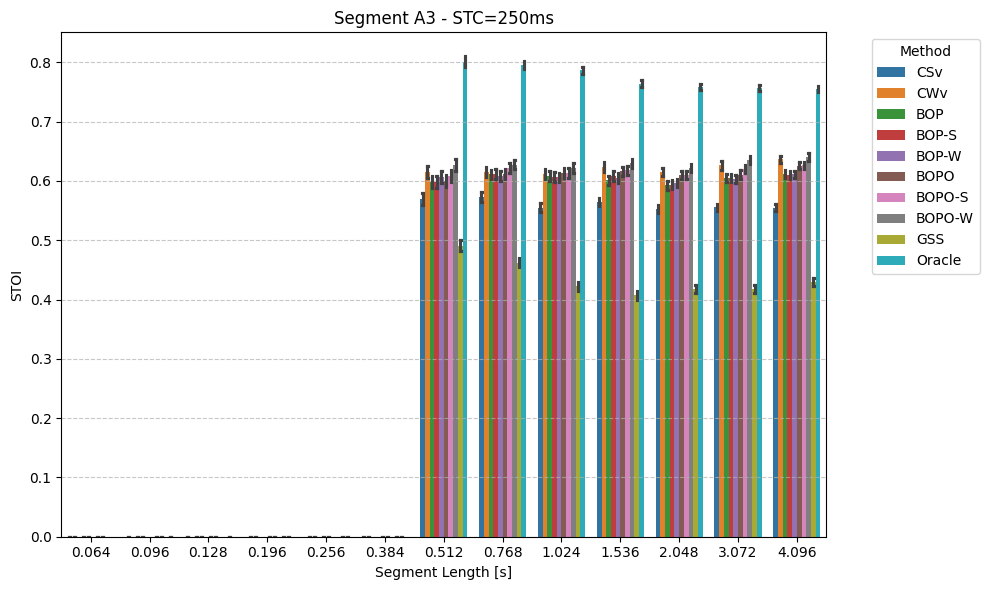

In [12]:
# Use seaborn to create a barplot showing the median of the selected metric
# with its std error of the median as error bars for each method,
# grouped by a another metric (usually a meta info like input SNR or segment length)
import seaborn as sns
import matplotlib.pyplot as plt
def plot_metric_by_group(
    df,
    metric,
    group_by,
    xlabel,
    title,
    ylabel,
    output_file,
):
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=df,
        x=group_by,
        y=metric,
        hue="method",
        errorbar="se",
        estimator=pd.Series.median,
        capsize=0.1,
    )
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(output_file)
    # plt.close()
    
# Now create plots for different metrics
metrics_to_plot = [
    ("WMHA", "WMHA [°]", "Utterance Level - STC=250ms"),
    ("WMHA_A2", "WMHA [°]", "Segment A2 - STC=250ms"),
    ("WMHA_A3", "WMHA [°]", "Segment A3 - STC=250ms"),
    ("DSINR", "SINR [dB]", "Utterance Level - STC=250ms"),
    ("DSINR_A2", "SINR [dB]", "Segment A2 - STC=250ms"),
    ("DSINR_A3", "SINR [dB]", "Segment A3 - STC=250ms"),
    ("STOIo", "STOI", "Utterance Level - STC=250ms"),
    ("STOIo_A2", "STOI", "Segment A2 - STC=250ms"),
    ("STOIo_A3", "STOI", "Segment A3 - STC=250ms"),
]
for metric, ylabel, title in metrics_to_plot:
    plot_metric_by_group(
        df_all,
        metric=metric,
        group_by="fixed_seg_length",#"fixed_seg_length", "input_snr"
        xlabel="Segment Length [s]", #"Segment Length [s]", "Input SNR [dB]"
        title=f"{title}",
        ylabel=ylabel,
        output_file=resultsdir / "plots" /f"{metric}_by_segment_length.png",
    )

In [ ]:
# # Use seaborn to create a barplot showing the median of the selected metric
# # with its std error of the median as error bars for each method,
# # grouped by a another metric (usually a meta info like input SNR or segment length)
# import seaborn as sns
# import matplotlib.pyplot as plt
# def plot_metric_by_group(
#     df,
#     metric,
#     group_by,
#     xlabel,
#     title,
#     ylabel,
#     output_file,
# ):
#     # 1. Determine order and calculate counts
#     # Get unique values and sort them to ensure consistent ordering
#     groups = sorted(df[group_by].unique())
#     # Calculate number of rows for each group value
#     counts = df[group_by].value_counts()
    
#     plt.figure(figsize=(10, 6))
    
#     # 2. Pass 'order' to ensure the plot follows our sorted groups
#     ax = sns.barplot(
#         data=df,
#         x=group_by,
#         y=metric,
#         hue="method",
#         errorbar="se",
#         estimator=pd.Series.median,
#         capsize=0.1,
#         order=groups, 
#     )
    
#     # 3. Create new labels with counts
#     # Example label: "0.5\n(N=1200)"
#     new_labels = [f"{g}\n({counts[g]})" for g in groups]
#     ax.set_xticklabels(new_labels)

#     ax.grid(True, axis='y', linestyle='--', alpha=0.7)
#     ax.set_title(title)
#     ax.set_ylabel(ylabel)
#     ax.set_xlabel(xlabel)
#     plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.tight_layout()
#     plt.savefig(output_file)
#     plt.close()
    
# # Now create plots for different metrics
# metrics_to_plot = [
#     ("WMHA_A2", "WMHA [°]", "Segment A2"),
#     ("WMHA_A3", "WMHA [°]", "Segment A3"),
#     ("DSINR_A2", "SINR [dB]", "Segment A2"),
#     ("DSINR_A3", "SINR [dB]", "Segment A3"),
#     ("STOIo_A2", "STOI", "Segment A2"),
#     ("STOIo_A3", "STOI", "Segment A3"),
# ]
# for metric, ylabel, title in metrics_to_plot:
#     plot_metric_by_group(
#         df_all,
#         metric=metric,
#         group_by="fixed_seg_length",
#         xlabel="Segment Length [s]",
#         title=f"{title}",
#         ylabel=ylabel,
#         output_file=resultsdir / "plots" /f"{metric}_by_segment_length.png",
#     )

/tmp/ipykernel_3570753/2457334270.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)
/tmp/ipykernel_3570753/2457334270.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)
/tmp/ipykernel_3570753/2457334270.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)
/tmp/ipykernel_3570753/2457334270.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)
/tmp/ipykernel_3570753/2457334270.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ne